In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

## **1. Gathering Data (Mengumpulkan Data)**
Dataset yang digunakan berisi data simulasi terkait perubahan iklim, pertanian, dan dampaknya terhadap hasil panen [Kaggle](https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture/data?select=climate_change_impact_on_agriculture_2024.csv). Dataset ini terdiri dari 10.000 baris dan 15 kolom. Detail dari masing-masing kolom dapat diuraikan sebagai berikut:

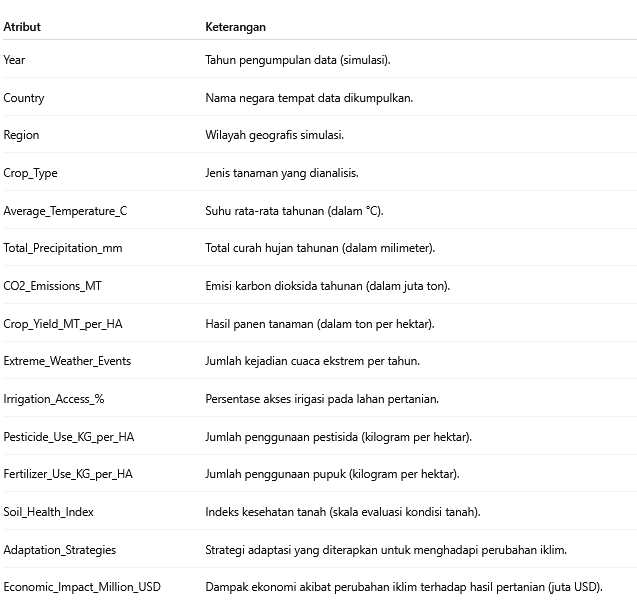

In [ ]:
df=pd.read_csv('/content/climate_change_impact_on_agriculture_2024.csv')

## **2. Menelaah Data**

#### Check Data Summary

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         10000 non-null  int64  
 1   Country                      10000 non-null  object 
 2   Region                       10000 non-null  object 
 3   Crop_Type                    10000 non-null  object 
 4   Average_Temperature_C        10000 non-null  float64
 5   Total_Precipitation_mm       10000 non-null  float64
 6   CO2_Emissions_MT             10000 non-null  float64
 7   Crop_Yield_MT_per_HA         10000 non-null  float64
 8   Extreme_Weather_Events       10000 non-null  int64  
 9   Irrigation_Access_%          10000 non-null  float64
 10  Pesticide_Use_KG_per_HA      10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA     10000 non-null  float64
 12  Soil_Health_Index            10000 non-null  float64
 13  Adaptation_Strate

**Insight**:

- Terdapat 15 kolom dalam dataset dengan 10.000 entri, dan tidak ada nilai kosong pada semua kolom (semua kolom memiliki 10.000 nilai non-null).

- Dataset terdiri dari 4 kolom kategorikal: Country, Region, Crop_Type, dan Adaptation_Strategies. Kolom-kolom ini berisi informasi yang mungkin dapat dianalisis lebih lanjut berdasarkan kategori negara, wilayah, jenis tanaman, dan strategi adaptasi.

- Terdapat 9 kolom numerik, yaitu: Average_Temperature_C, Total_Precipitation_mm, CO2_Emissions_MT, Crop_Yield_MT_per_HA, Extreme_Weather_Events, Irrigation_Access_%, Pesticide_Use_KG_per_HA, Fertilizer_Use_KG_per_HA, dan Soil_Health_Index.

- Kolom Year berisi informasi tentang tahun, yang bisa digunakan untuk melihat tren atau perubahan sepanjang waktu, dan dapat dikonversi menjadi tipe datetime jika diperlukan analisis berbasis waktu lebih lanjut.

- Kolom Economic_Impact_Million_USD berisi nilai ekonomi yang dapat dianalisis dalam kaitannya dengan faktor-faktor lainnya, seperti iklim, penggunaan air irigasi, dan pemakaian pupuk/pestisida.

In [ ]:
df.describe()

,Year,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Economic_Impact_Million_USD
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2007.088700,15.241299,1611.663834,15.246608,2.240017,4.980900,55.248332,24.955735,49.973708,64.901278,674.269658
std,10.084245,11.466955,805.016815,8.589423,0.998342,3.165808,25.988305,14.490962,28.711027,20.195882,414.591431
min,1990.000000,-4.990000,200.150000,0.500000,0.450000,0.000000,10.010000,0.000000,0.010000,30.000000,47.840000
25%,1999.000000,5.430000,925.697500,7.760000,1.449000,2.000000,32.677500,12.527500,25.390000,47.235000,350.545000
50%,2007.000000,15.175000,1611.160000,15.200000,2.170000,5.000000,55.175000,24.930000,49.635000,64.650000,583.920000
75%,2016.000000,25.340000,2306.997500,22.820000,2.930000,8.000000,77.582500,37.470000,74.825000,82.472500,917.505000
max,2024.000000,35.000000,2999.670000,30.000000,5.000000,10.000000,99.990000,49.990000,99.990000,100.000000,2346.470000


**Insight:**

- Dataset memiliki 10.000 baris data lengkap tanpa missing value untuk seluruh kolom numerik.

- Rentang data tahun berada antara 1990 hingga 2024, dengan rata-rata tahun sekitar 2007.

- Suhu rata-rata bervariasi dari sekitar -5 °C hingga 35 °C, dengan rata-rata suhu 15.24 °C.

- Curah hujan tahunan tercatat mulai dari 200 mm hingga hampir 3000 mm, dengan rata-rata sekitar 1612 mm.

- Emisi CO₂ per tahun berkisar antara 0.5 hingga 30 juta ton, dengan rata-rata 15.25 juta ton.

- Hasil panen (Crop Yield) berkisar antara 0.45 hingga 5 ton per hektar, dengan nilai rata-rata 2.24 ton per hektar.

- Jumlah kejadian cuaca ekstrem per tahun berkisar antara 0 hingga 10 kejadian, dengan rata-rata sekitar 5 kejadian.

- Akses irigasi di lahan pertanian bervariasi dari 10% hingga hampir 100%, dengan rata-rata sekitar 55%.

- Penggunaan pestisida dan pupuk menunjukkan variasi cukup besar, masing-masing dengan rata-rata sekitar 25 kg/ha dan 50 kg/ha.

- Indeks kesehatan tanah berkisar antara 30 hingga 100, dengan rata-rata nilai kesehatan tanah sekitar 65.

- Dampak ekonomi akibat perubahan iklim tercatat antara 47 hingga 2346 juta USD, dengan rata-rata sekitar 674 juta USD.

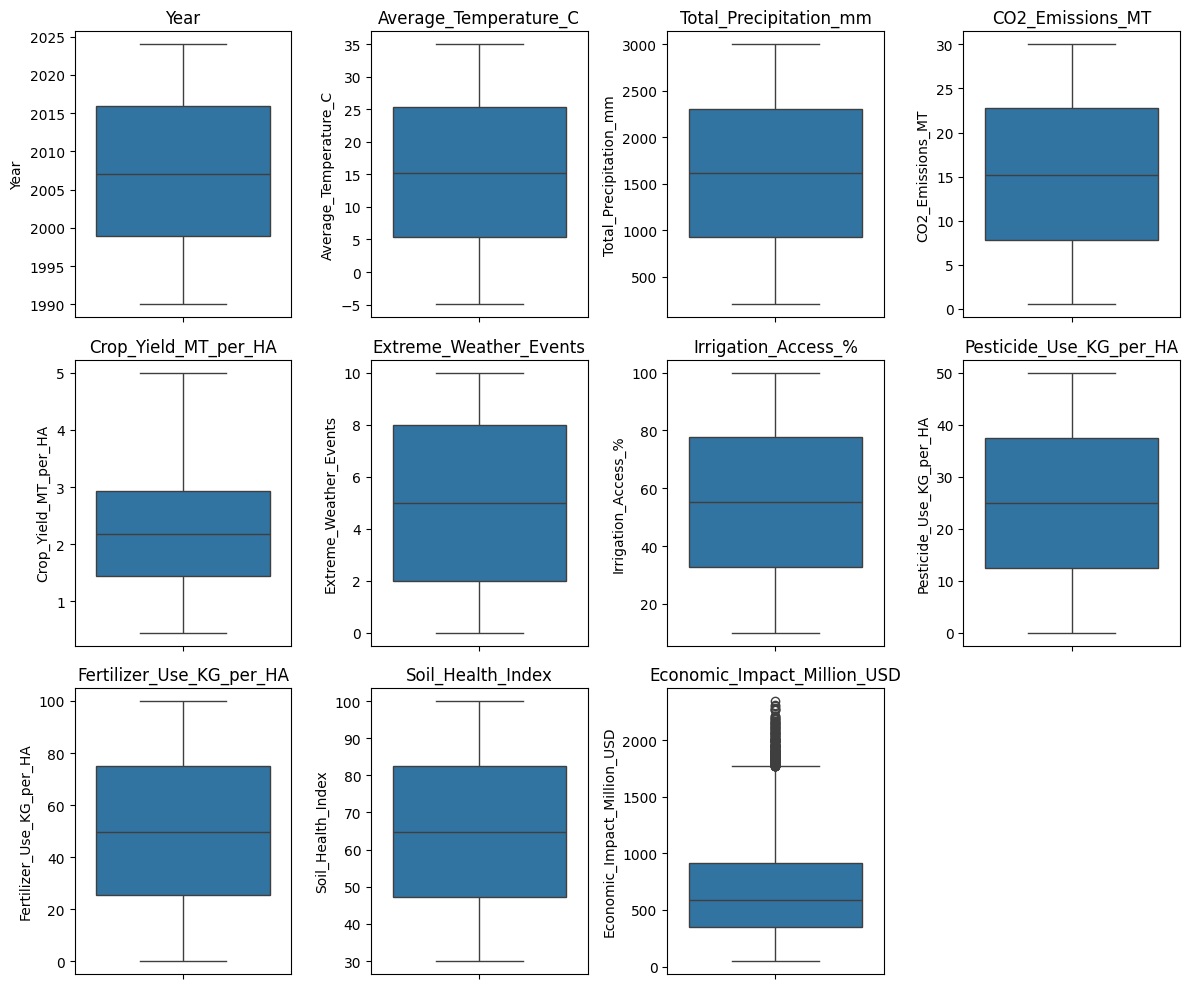

In [ ]:
numeric_cols = ['Year', 'Average_Temperature_C', 'Total_Precipitation_mm', 'CO2_Emissions_MT',
                'Crop_Yield_MT_per_HA', 'Extreme_Weather_Events', 'Irrigation_Access_%',
                'Pesticide_Use_KG_per_HA', 'Fertilizer_Use_KG_per_HA', 'Soil_Health_Index', 'Economic_Impact_Million_USD']


plt.figure(figsize=(12, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

**Insight:**

- Terlihat bahwa semua fitur pada kolom kategorikal (Country, Region, Crop_Type, Adaptation_Strategies) tidak menunjukkan adanya outlier berdasarkan visualisasi boxplot yang telah dilakukan. Namun, pemeriksaan lebih lanjut akan dilakukan pada tahap pembersihan data untuk memastikan tidak ada nilai yang tidak wajar.

- Kolom Crop_Yield_MT_per_HA dan Economic_Impact_Million_USD menunjukkan distribusi skewed right (positively skewed), yang mengindikasikan adanya ekor panjang di sisi kanan. Untuk menjaga kenormalan data dan mengurangi skewness, transformasi menggunakan metode Box-Cox akan diterapkan pada kolom ini.

#### Check Unique Value

In [ ]:
for col in numeric_cols:
  print(f"Value counts for {col}:\n{df[col].value_counts()}\n")


Value counts for Year:
Year
1999    335
2019    317
1991    314
2012    313
2004    307
1994    305
2013    305
2001    300
1996    295
2015    294
2023    294
2008    293
2016    293
2021    292
2002    289
2022    288
1997    287
2009    285
2003    285
2000    284
2024    281
2010    281
2014    281
2020    278
1995    277
2005    275
2017    275
1992    274
2011    273
2018    272
2007    262
1993    257
1990    250
2006    250
1998    239
Name: count, dtype: int64

Value counts for Average_Temperature_C:
Average_Temperature_C
20.35    9
3.41     9
33.19    9
15.09    8
11.75    8
        ..
26.21    1
34.47    1
22.07    1
24.12    1
13.57    1
Name: count, Length: 3677, dtype: int64

Value counts for Total_Precipitation_mm:
Total_Precipitation_mm
1377.47    3
2001.52    2
1061.47    2
1045.38    2
798.65     2
          ..
1841.78    1
2388.71    1
1061.11    1
1549.97    1
2181.96    1
Name: count, Length: 9784, dtype: int64

Value counts for CO2_Emissions_MT:
CO2_Emissions_MT
2

**Insight:**

- Setelah melakukan pengecekan terhadap distribusi nilai di setiap kolom, tidak terlihat adanya nilai ekstrem yang mencurigakan. Semua kolom numerik menunjukkan distribusi yang wajar tanpa adanya outlier yang signifikan, meskipun beberapa kolom seperti Crop_Yield_MT_per_HA dan Irrigation_Access_% memiliki nilai yang lebih terpusat, yang mungkin merefleksikan data yang konsisten di wilayah atau waktu tertentu. Namun, secara keseluruhan, data tampaknya tidak mengandung nilai yang menyimpang jauh dari pola umum.

In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    print(df[col].value_counts(dropna=False))
    print("-" * 20)

Country
Australia    1032
USA          1032
China        1031
Nigeria      1029
India        1025
Canada        984
Argentina     984
France        978
Russia        961
Brazil        944
Name: count, dtype: int64
--------------------
Region
South                         754
Northeast                     752
North                         524
Central                       466
Punjab                        288
Victoria                      283
New South Wales               276
East                          273
South West                    270
Ontario                       269
West Bengal                   267
North West                    264
Volga                         261
South East                    260
West                          257
Grand Est                     254
Midwest                       253
Queensland                    253
Nouvelle-Aquitaine            252
Tamil Nadu                    249
Patagonia                     249
Northwest                     247
Siberian  

In [ ]:
import plotly.express as px

# Pie chart buat Country
country_counts = df['Country'].value_counts()
fig_country = px.pie(country_counts, values=country_counts.values, names=country_counts.index, title='Distribution of Countries')
fig_country.show()


# Pareto chart buat Region
region_counts = df['Region'].value_counts()
pareto_df = pd.DataFrame({'Region': region_counts.index, 'Count': region_counts.values})
pareto_df = pareto_df.sort_values(by='Count', ascending=False)
pareto_df['Cumulative_Percentage'] = (pareto_df['Count'].cumsum() / pareto_df['Count'].sum()) * 100

fig_pareto = px.bar(pareto_df, x='Region', y='Count', title='Pareto Chart for Region')
fig_pareto.add_scatter(x=pareto_df['Region'], y=pareto_df['Cumulative_Percentage'], mode='lines+markers', name='Cumulative Percentage')
fig_pareto.show()


# Bar chart buat Crop_Type sama Adaptation_Strategies
fig_crop = px.histogram(df, x='Crop_Type', title='Distribution of Crop Types', color='Adaptation_Strategies', barmode='group')
fig_crop.show()


Insight:
- Tidak ada inkonsistensi data pada semua kolom kategorik
- Secara keseluruhan, distribusi Country dalam dataset relatif merata, dengan sekitar 9-10% untuk masing-masing negara.
- Strategi Adaptasi untuk Jenis Tanaman:
  1. Tanaman corn paling banyak menggunakan strategi adaptasi no adaptation.

  2. Tanaman wheat paling sering menggunakan strategi crop rotation.

  3. Tanaman coffee dominan menggunakan water management dan organic farming.

  4. Tanaman sugarcane paling sering menerapkan water management.

  5. Tanaman vegetables juga banyak menggunakan water management.

  6. Tanaman rice sebagian besar tercatat tidak melakukan adaptasi.

  7. Tanaman soy beans banyak yang tercatat tidak melakukan adaptasi.

  8. Tanaman barley umumnya mengadopsi strategi crop rotation.

  9. Tanaman fruits banyak yang tidak melakukan adaptasi.

  10. Tanaman cotton sering menggunakan strategi drought-resistant crops.



> _Sebenarnya semua tanaman menggunakan berbagai strategi adaptasi, hanya saja perbedaannya antar strategi cukup kecil, dan daftar di atas menunjukkan adaptasi yang paling sering muncul untuk masing-masing tanaman._



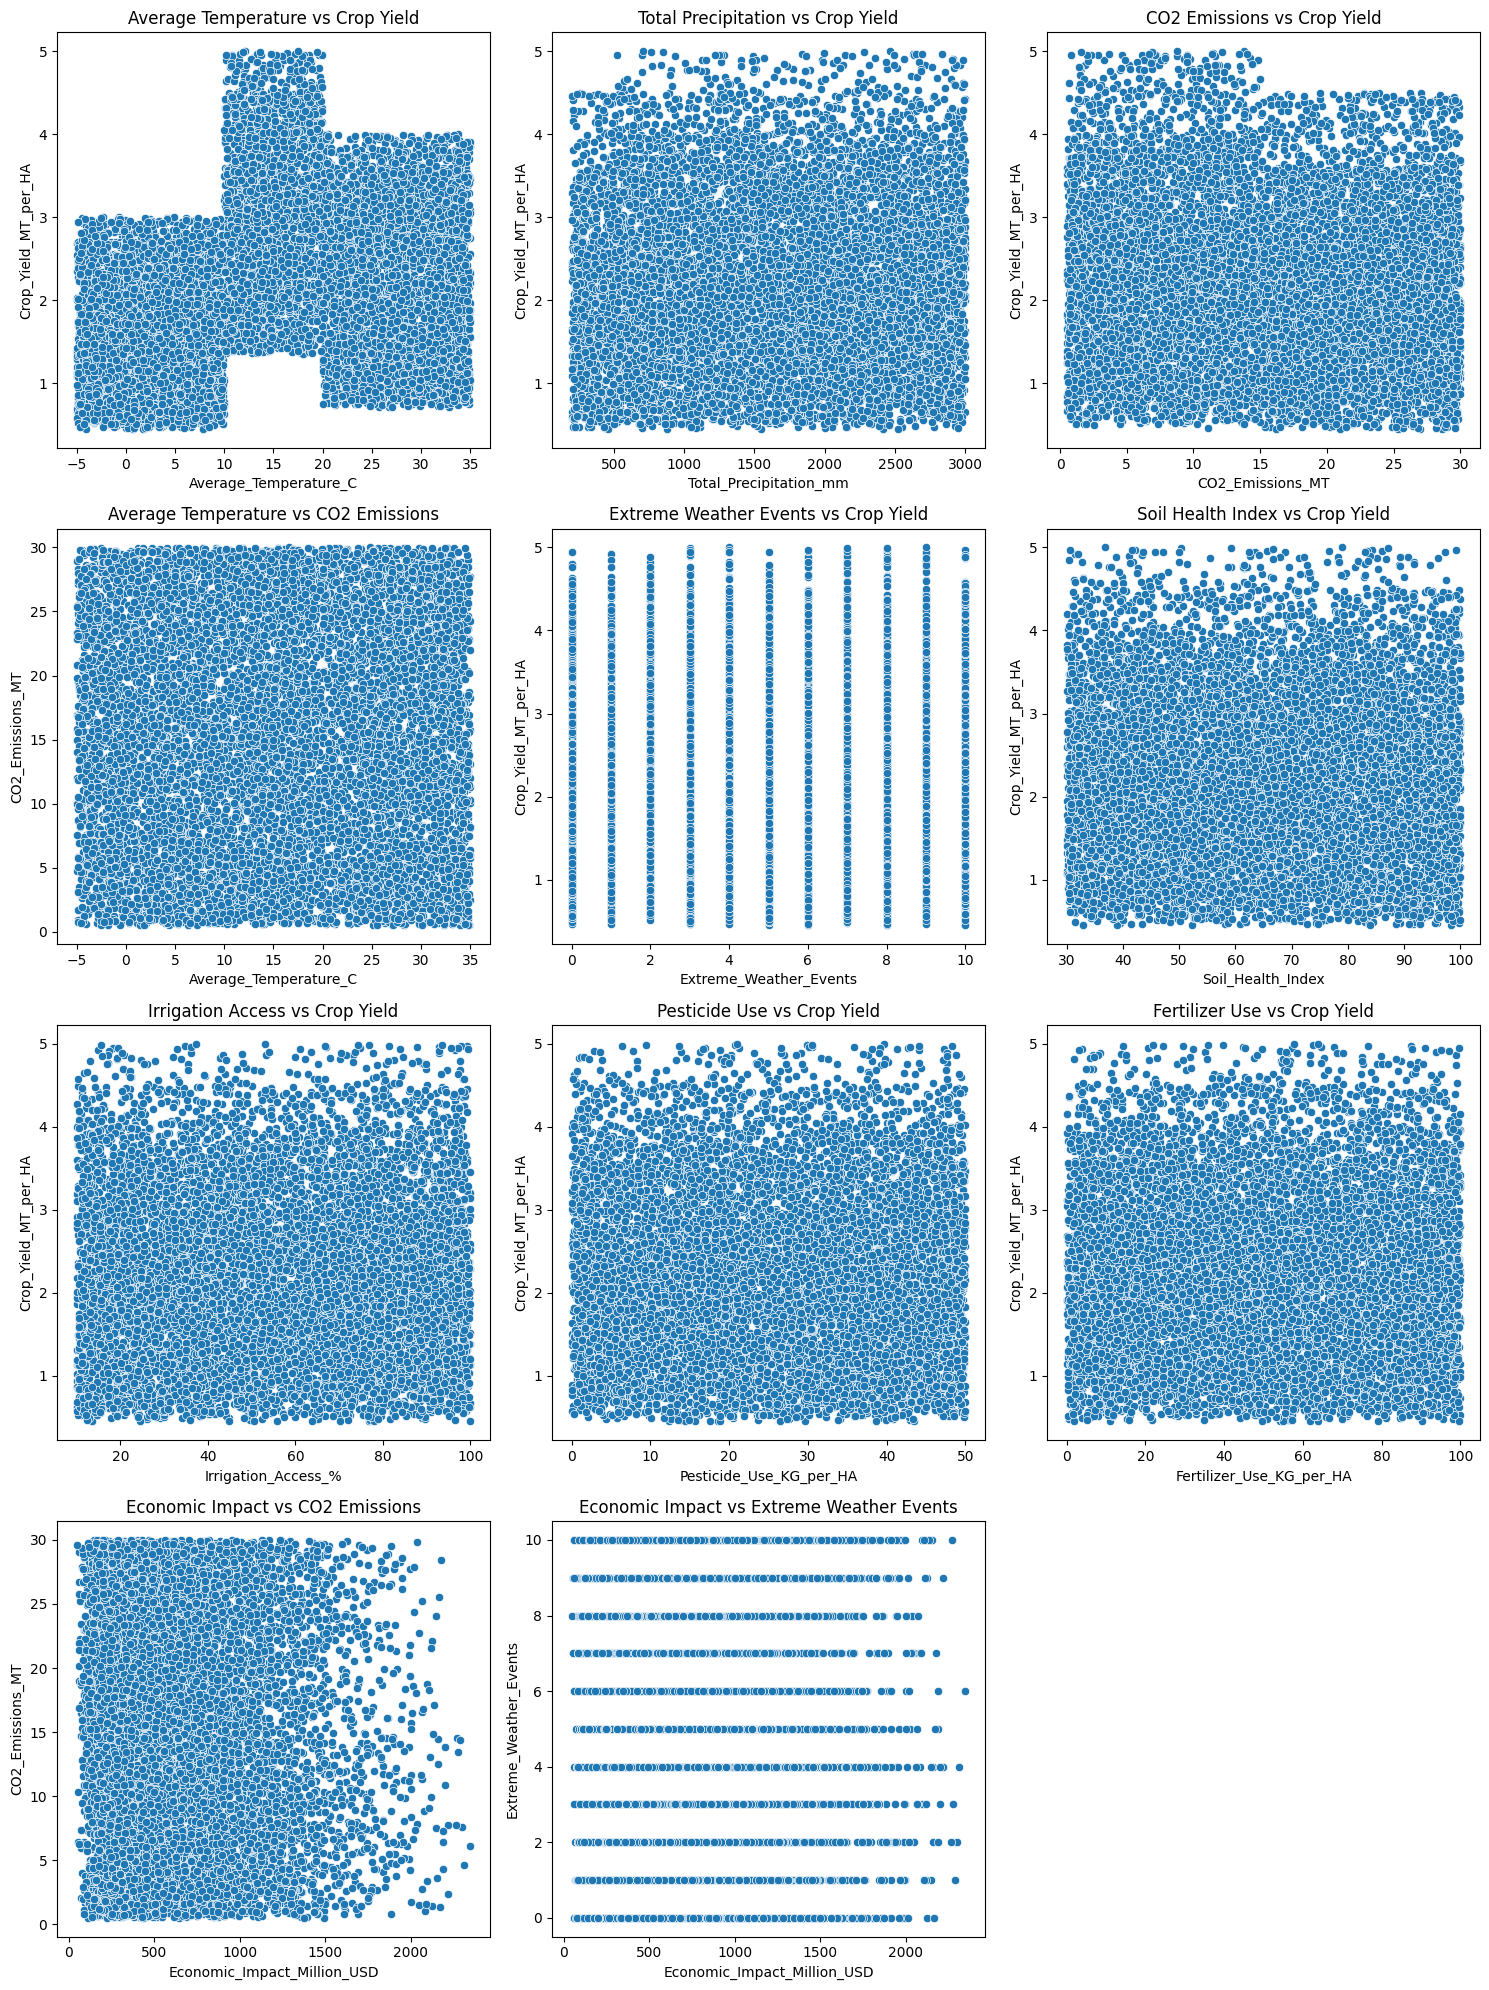

In [ ]:
plt.figure(figsize=(15, 20))

plt.subplot(4, 3, 1)
sns.scatterplot(x='Average_Temperature_C', y='Crop_Yield_MT_per_HA', data=df, palette='viridis')
plt.title('Average Temperature vs Crop Yield')

plt.subplot(4, 3, 2)
sns.scatterplot(x='Total_Precipitation_mm', y='Crop_Yield_MT_per_HA', data=df, palette='viridis')
plt.title('Total Precipitation vs Crop Yield')

plt.subplot(4, 3, 3)
sns.scatterplot(x='CO2_Emissions_MT', y='Crop_Yield_MT_per_HA', data=df, palette='viridis')
plt.title('CO2 Emissions vs Crop Yield')

plt.subplot(4, 3, 4)
sns.scatterplot(x='Average_Temperature_C', y='CO2_Emissions_MT', data=df, palette='viridis')
plt.title('Average Temperature vs CO2 Emissions')

plt.subplot(4, 3, 5)
sns.scatterplot(x='Extreme_Weather_Events', y='Crop_Yield_MT_per_HA', data=df, palette='viridis')
plt.title('Extreme Weather Events vs Crop Yield')

plt.subplot(4, 3, 6)
sns.scatterplot(x='Soil_Health_Index', y='Crop_Yield_MT_per_HA', data=df, palette='viridis')
plt.title('Soil Health Index vs Crop Yield')

plt.subplot(4, 3, 7)
sns.scatterplot(x='Irrigation_Access_%', y='Crop_Yield_MT_per_HA', data=df, palette='viridis')
plt.title('Irrigation Access vs Crop Yield')

plt.subplot(4, 3, 8)
sns.scatterplot(x='Pesticide_Use_KG_per_HA', y='Crop_Yield_MT_per_HA', data=df, palette='viridis')
plt.title('Pesticide Use vs Crop Yield')

plt.subplot(4, 3, 9)
sns.scatterplot(x='Fertilizer_Use_KG_per_HA', y='Crop_Yield_MT_per_HA', data=df, palette='viridis')
plt.title('Fertilizer Use vs Crop Yield')

plt.subplot(4, 3, 10)
sns.scatterplot(x='Economic_Impact_Million_USD', y='CO2_Emissions_MT', data=df, palette='viridis')
plt.title('Economic Impact vs CO2 Emissions')

plt.subplot(4, 3, 11)
sns.scatterplot(x='Economic_Impact_Million_USD', y='Extreme_Weather_Events', data=df, palette='viridis')
plt.title('Economic Impact vs Extreme Weather Events')

plt.tight_layout()
plt.show()


**Insight:**
- Kebanyakan scaterplott tidak dapat ditarik kesimpulan secara langsung
- Pada Scatterplot pertama terlihat segmentasi yang sangat jelas. Suhu rendah (sekitar -5 hingga 10 °C) cenderung menghasilkan panen rendah hingga sedang (0.5 hingga 3 MT/Ha), sementara suhu sedang (sekitar 10 hingga 20 °C) menghasilkan panen tinggi (3 hingga 5 MT/Ha). Suhu tinggi (sekitar 20 hingga 35 °C) biasanya menghasilkan panen rendah hingga sedang (0.5 hingga 4 MT/Ha).

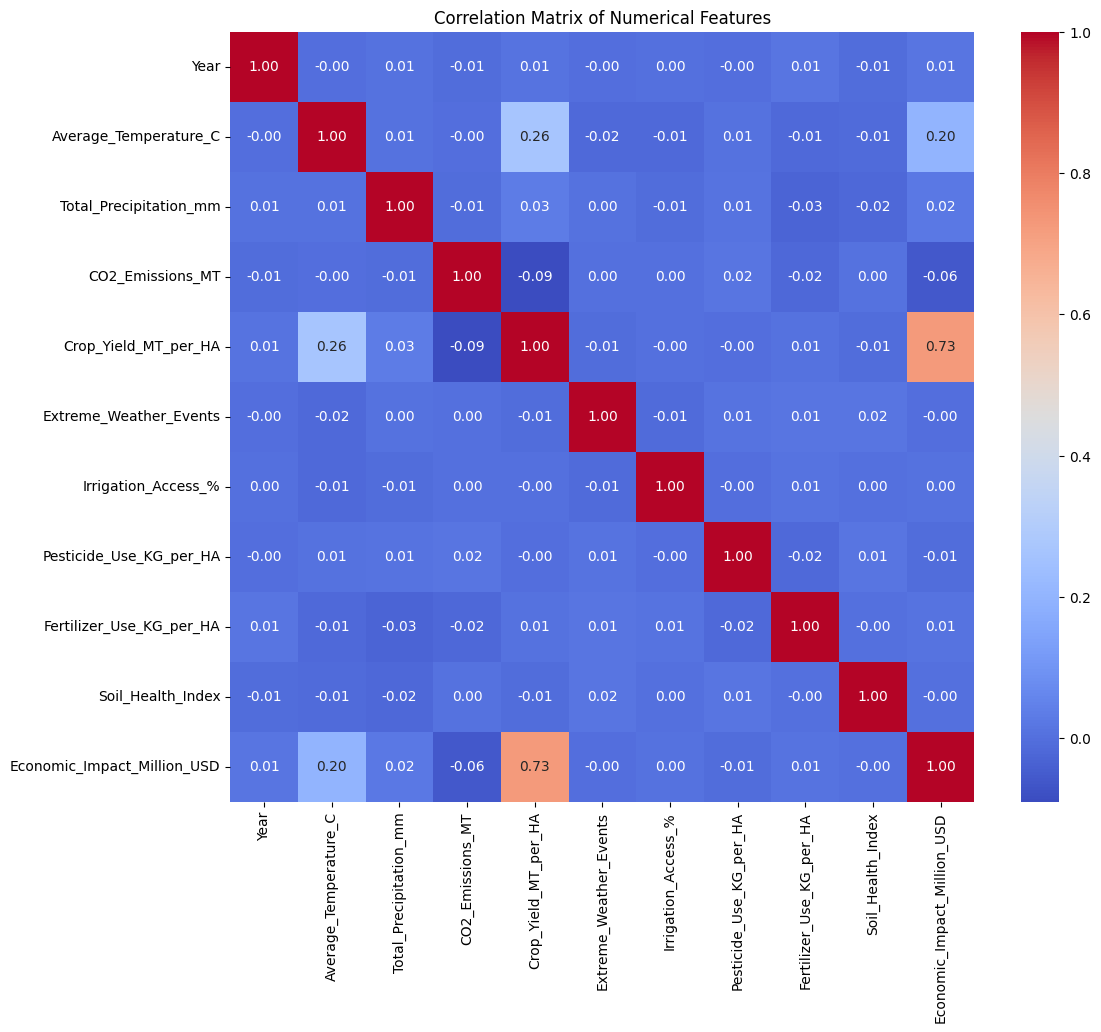

In [ ]:
plt.figure(figsize=(12, 10))
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


Insight:

  -  Terdapat korelasi positif kuat antara Crop Yield dan Economic Impact (0.73).

  -  Terdapat korelasi positif sedang antara Crop Yield dan Total Precipitation (0.26).

  - Terdapat korelasi positif lemah antara Average Temperature dan Economic Impact (0.20).
  
  -  Sebagian besar fitur lain menunjukkan korelasi sangat lemah atau mendekati nol, seperti antara Extreme Weather Events, Irrigation Access, Pesticide Use, Fertilizer Use, Soil Health Index, dan variabel lainnya.


## **3. Validasi Data**

#### Check Missing Values

In [ ]:
df.isnull().sum()


,0
Year,0
Country,0
Region,0
Crop_Type,0
Average_Temperature_C,0
Total_Precipitation_mm,0
CO2_Emissions_MT,0
Crop_Yield_MT_per_HA,0
Extreme_Weather_Events,0
Irrigation_Access_%,0


### TRansformasi Data


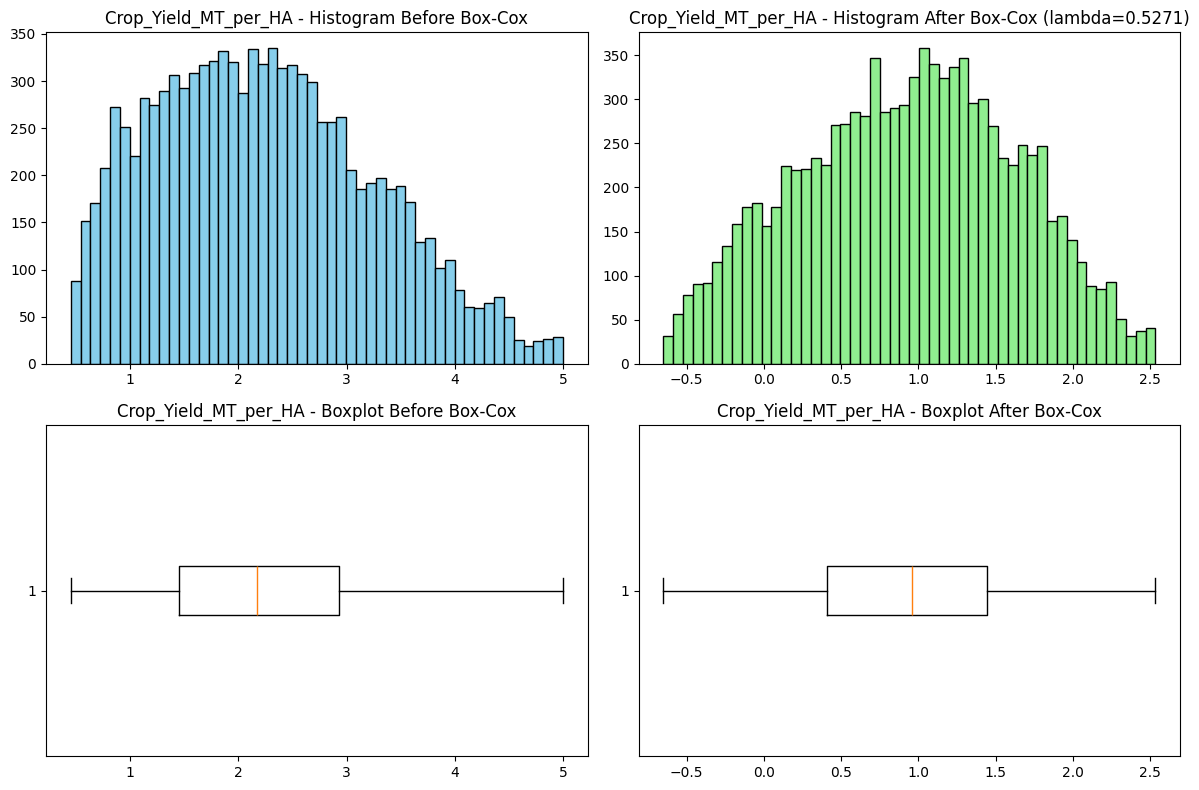

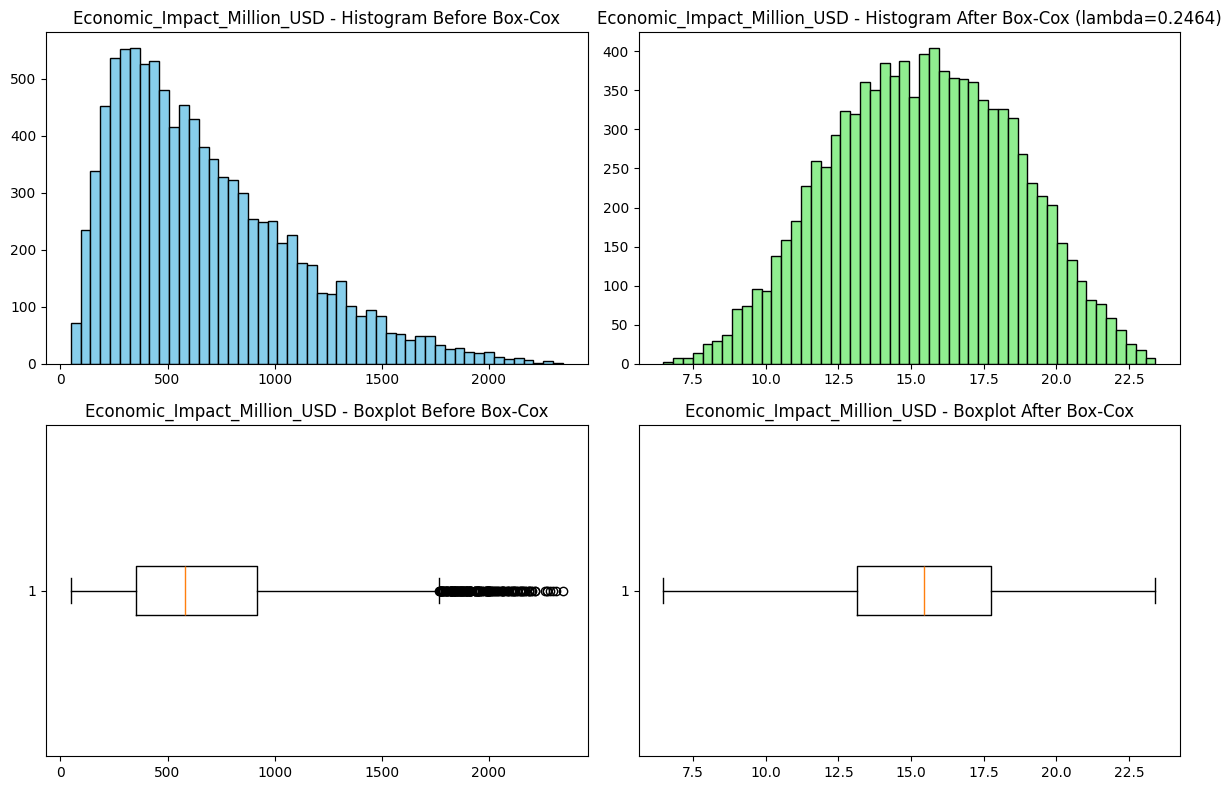


Lambda hasil Box-Cox:
Crop_Yield_MT_per_HA: 0.5271
Economic_Impact_Million_USD: 0.2464

Descriptive statistics setelah transformasi:
       Crop_Yield_MT_per_HA  Economic_Impact_Million_USD
count          10000.000000                 10000.000000
mean               0.928072                    15.415740
std                0.699696                     3.115796
min               -0.651753                     6.467156
25%                0.409607                    13.134805
50%                0.956836                    15.438151
75%                1.446269                    17.734333
max                2.534175                    23.407128


In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import boxcox

# Kolom yang mau ditransformasi
cols_to_transform = ['Crop_Yield_MT_per_HA', 'Economic_Impact_Million_USD']

# Simpen lambda hasil transformasi
lambdas = {}

# Simpen data sebelum transformasi buat boxplot
df_before = df[cols_to_transform].copy()

# Plot histogram dan boxplot sebelum dan sesudah transformasi
for col in cols_to_transform:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Histogram sebelum transformasi
    axes[0, 0].hist(df_before[col], bins=50, color='skyblue', edgecolor='black')
    axes[0, 0].set_title(f'{col} - Histogram Before Box-Cox')

    # Boxplot sebelum transformasi
    axes[1, 0].boxplot(df_before[col], vert=False)
    axes[1, 0].set_title(f'{col} - Boxplot Before Box-Cox')

    # Transformasi Box-Cox
    df[col], fitted_lambda = boxcox(df[col])
    lambdas[col] = fitted_lambda

    # Histogram setelah transformasi
    axes[0, 1].hist(df[col], bins=50, color='lightgreen', edgecolor='black')
    axes[0, 1].set_title(f'{col} - Histogram After Box-Cox (lambda={fitted_lambda:.4f})')

    # Boxplot setelah transformasi
    axes[1, 1].boxplot(df[col], vert=False)
    axes[1, 1].set_title(f'{col} - Boxplot After Box-Cox')

    plt.tight_layout()
    plt.show()

# Print hasil lambda
print("\nLambda hasil Box-Cox:")
for col, lamb in lambdas.items():
    print(f"{col}: {lamb:.4f}")

# Cek deskripsi setelah transformasi
print("\nDescriptive statistics setelah transformasi:")
print(df[cols_to_transform].describe())


**Insight:**

- Kolom Crop_Yield_MT_per_HA dan Economic_Impact_Million_USD awalnya memiliki distribusi yang skewed (condong) ke kanan. Setelah dilakukan transformasi Box-Cox, distribusi kedua kolom menjadi lebih simetris dan mendekati distribusi normal.

- Nilai lambda hasil transformasi:

 - Crop_Yield_MT_per_HA: 0.5271

  -Economic_Impact_Million_USD: 0.2464

- Hasil deskriptif setelah transformasi menunjukkan bahwa:

  - Crop_Yield_MT_per_HA memiliki penyebaran data yang lebih merata, dengan nilai tengah (median) mendekati rata-rata (mean), yaitu 0.9568 dan 0.9281, menunjukkan distribusi yang lebih seimbang.

  - Economic_Impact_Million_USD juga memperlihatkan distribusi yang jauh lebih stabil, dengan median (15.44) sangat dekat dengan mean (15.42), serta range antar kuartil (IQR) yang seimbang.

- Selain itu, berdasarkan boxplot setelah transformasi, kolom Economic_Impact_Million_USD sudah tidak menunjukkan adanya outlier ekstrem, memperkuat stabilitas data untuk analisis lebih lanjut.

## **4. Menentukan Objek Data**

**Tujuan Analisis**

Tujuan dari analisis ini adalah untuk memahami bagaimana faktor-faktor iklim (seperti suhu rata-rata, curah hujan, dan emisi CO₂) serta faktor agrikultur (seperti akses irigasi, penggunaan pestisida, penggunaan pupuk, dan indeks kesehatan tanah) mempengaruhi hasil produksi tanaman (Crop_Yield_MT_per_HA) dan dampak ekonominya (Economic_Impact_Million_USD). Rencana Sementara

1. Random Forest Regressor → untuk memprediksi Crop Yield dan sekalian mengukur feature importance.

2. Neural Network (NN) → untuk memprediksi Crop Yield dengan pendekatan model non-linear yang lebih kompleks.
3. 3B (Clustering).
4. Regression Analysis untuk Economic Impact

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         10000 non-null  int64  
 1   Country                      10000 non-null  object 
 2   Region                       10000 non-null  object 
 3   Crop_Type                    10000 non-null  object 
 4   Average_Temperature_C        10000 non-null  float64
 5   Total_Precipitation_mm       10000 non-null  float64
 6   CO2_Emissions_MT             10000 non-null  float64
 7   Crop_Yield_MT_per_HA         10000 non-null  float64
 8   Extreme_Weather_Events       10000 non-null  int64  
 9   Irrigation_Access_%          10000 non-null  float64
 10  Pesticide_Use_KG_per_HA      10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA     10000 non-null  float64
 12  Soil_Health_Index            10000 non-null  float64
 13  Adaptation_Strate

### Correcting Data Types
Proses ini bertujuan untuk merubah tipe data yang belum sesuai dari kolom-kolom dataset yang ada. Opsi yang akan dilakukan adalah merubah kolom yang bertipe kategorik menjadi numerik.

In [ ]:
obj = ['Country', 'Region', 'Crop_Type', 'Adaptation_Strategies']
for col in obj:
  print(df[col].unique())

['India' 'China' 'France' 'Canada' 'USA' 'Argentina' 'Australia' 'Nigeria'
 'Russia' 'Brazil']
['West Bengal' 'North' 'Ile-de-France' 'Prairies' 'Tamil Nadu' 'Midwest'
 'Northeast' 'New South Wales' 'Punjab' 'North West' 'South East'
 'Grand Est' 'Northwestern' 'Siberian' 'Northwest' 'Victoria'
 'Nouvelle-Aquitaine' 'South' 'Quebec' 'Southeast' 'Ontario' 'East'
 'Pampas' 'Western Australia' 'Volga' 'Maharashtra'
 'Provence-Alpes-Cote d’Azur' 'West' 'Central' 'North Central' 'Patagonia'
 'Queensland' 'South West' 'British Columbia']
['Corn' 'Wheat' 'Coffee' 'Sugarcane' 'Fruits' 'Rice' 'Barley' 'Vegetables'
 'Soybeans' 'Cotton']
['Water Management' 'Crop Rotation' 'No Adaptation' 'Organic Farming'
 'Drought-resistant Crops']


### Label Encoding


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df['Country_Original'] = df['Country']
df['Region_Original'] = df['Region']
df['Crop_Type_Original'] = df['Crop_Type']
df['Adaptation_Strategies_Original'] = df['Adaptation_Strategies']

label_encoders = {}

categorical_cols = ['Country', 'Region', 'Crop_Type', 'Adaptation_Strategies']
encoded_col_names = ['Country_Label', 'Region_Label', 'Crop_Label', 'Adapt_Label']

# Proses encoding untuk tiap kolom
for col, new_col in zip(categorical_cols, encoded_col_names):
    le = LabelEncoder()
    df[new_col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Simpan encoder-nya kalau ingin inverse transform nanti

# Tampilkan hasil label encoding
print("Label Encoding Mappings:")
for col, new_col in zip(categorical_cols, encoded_col_names):
    le = label_encoders[col]
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col}: {mapping}")


Label Encoding Mappings:
Country: {'Argentina': np.int64(0), 'Australia': np.int64(1), 'Brazil': np.int64(2), 'Canada': np.int64(3), 'China': np.int64(4), 'France': np.int64(5), 'India': np.int64(6), 'Nigeria': np.int64(7), 'Russia': np.int64(8), 'USA': np.int64(9)}
Region: {'British Columbia': np.int64(0), 'Central': np.int64(1), 'East': np.int64(2), 'Grand Est': np.int64(3), 'Ile-de-France': np.int64(4), 'Maharashtra': np.int64(5), 'Midwest': np.int64(6), 'New South Wales': np.int64(7), 'North': np.int64(8), 'North Central': np.int64(9), 'North West': np.int64(10), 'Northeast': np.int64(11), 'Northwest': np.int64(12), 'Northwestern': np.int64(13), 'Nouvelle-Aquitaine': np.int64(14), 'Ontario': np.int64(15), 'Pampas': np.int64(16), 'Patagonia': np.int64(17), 'Prairies': np.int64(18), 'Provence-Alpes-Cote d’Azur': np.int64(19), 'Punjab': np.int64(20), 'Quebec': np.int64(21), 'Queensland': np.int64(22), 'Siberian': np.int64(23), 'South': np.int64(24), 'South East': np.int64(25), 'South 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Year                            10000 non-null  int64  
 1   Country                         10000 non-null  object 
 2   Region                          10000 non-null  object 
 3   Crop_Type                       10000 non-null  object 
 4   Average_Temperature_C           10000 non-null  float64
 5   Total_Precipitation_mm          10000 non-null  float64
 6   CO2_Emissions_MT                10000 non-null  float64
 7   Crop_Yield_MT_per_HA            10000 non-null  float64
 8   Extreme_Weather_Events          10000 non-null  int64  
 9   Irrigation_Access_%             10000 non-null  float64
 10  Pesticide_Use_KG_per_HA         10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA        10000 non-null  float64
 12  Soil_Health_Index               1

### Melihat Feature important

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Year                            10000 non-null  int64  
 1   Country                         10000 non-null  object 
 2   Region                          10000 non-null  object 
 3   Crop_Type                       10000 non-null  object 
 4   Average_Temperature_C           10000 non-null  float64
 5   Total_Precipitation_mm          10000 non-null  float64
 6   CO2_Emissions_MT                10000 non-null  float64
 7   Crop_Yield_MT_per_HA            10000 non-null  float64
 8   Extreme_Weather_Events          10000 non-null  int64  
 9   Irrigation_Access_%             10000 non-null  float64
 10  Pesticide_Use_KG_per_HA         10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA        10000 non-null  float64
 12  Soil_Health_Index               1

In [ ]:
# Impor modul yang dibutuhkan
from sklearn.ensemble import RandomForestRegressor

# Kolom-kolom yang harus di-drop:
cols_to_drop = [
    'Crop_Yield_MT_per_HA',        # target
    'Country', 'Region', 'Crop_Type', 'Adaptation_Strategies',  # kolom asli kategori (string)
    'Country_Original', 'Region_Original', 'Crop_Type_Original', 'Adaptation_Strategies_Original'  # kolom backup kategori (string)
]

X = df.drop(columns=cols_to_drop)
y = df['Crop_Yield_MT_per_HA']

# Latih model Random Forest untuk melihat feature importance
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

# Menampilkan feature importance
importances = rf.feature_importances_
feature_names = X.columns

# Urutkan fitur berdasarkan pentingnya
sorted_indices = importances.argsort()[::-1]
sorted_importances = importances[sorted_indices]
sorted_features = feature_names[sorted_indices]

# Tampilkan hasil
for feature, importance in zip(sorted_features, sorted_importances):
    print(f"Feature: {feature}, Importance: {importance:.4f}")


Feature: Economic_Impact_Million_USD, Importance: 0.5983
Feature: Average_Temperature_C, Importance: 0.1058
Feature: CO2_Emissions_MT, Importance: 0.0354
Feature: Pesticide_Use_KG_per_HA, Importance: 0.0321
Feature: Total_Precipitation_mm, Importance: 0.0320
Feature: Fertilizer_Use_KG_per_HA, Importance: 0.0312
Feature: Irrigation_Access_%, Importance: 0.0312
Feature: Soil_Health_Index, Importance: 0.0304
Feature: Year, Importance: 0.0237
Feature: Region_Label, Importance: 0.0220
Feature: Extreme_Weather_Events, Importance: 0.0165
Feature: Crop_Label, Importance: 0.0159
Feature: Country_Label, Importance: 0.0148
Feature: Adapt_Label, Importance: 0.0106


**Insight:**
- Berdasarkan hasil Random Forest Regressor, fitur Economic_Impact_Million_USD menjadi faktor paling dominan dalam menentukan Crop Yield, dengan kontribusi sekitar 59.85% terhadap model prediksi.

- Faktor iklim seperti Average_Temperature_C (10.63%) dan CO2_Emissions_MT (3.55%) juga berpengaruh, namun dengan bobot yang jauh lebih kecil dibandingkan faktor ekonomi.

- Faktor-faktor agrikultur lainnya seperti Pesticide_Use_KG_per_HA, Total_Precipitation_mm, Fertilizer_Use_KG_per_HA, dan Irrigation_Access_% memiliki kontribusi serupa, masing-masing di kisaran 3%.

- Faktor seperti Soil_Health_Index dan Extreme_Weather_Events juga memberikan kontribusi, namun lebih kecil dibandingkan faktor ekonomi dan iklim.

- Faktor kategori seperti Region, Country, Crop_Type, dan Adaptation_Strategies memiliki kontribusi penting namun lebih rendah (di bawah 2.5%), menunjukkan bahwa variabel lokasi dan jenis tanaman tetap berpengaruh, meski tidak dominan.

## Hipotesis Awal

#### 1. Hipotesis Awal

Hipotesis awal menyatakan bahwa **`Country` dan `Region` tidak memberikan dampak langsung** terhadap *Crop Yield* maupun *Economic Impact*, karena:

* Fokus utama adalah untuk menganalisis **pengaruh langsung dari variabel iklim dan agrikultur** (misalnya: suhu, curah hujan, emisi CO₂, irigasi, pupuk, dll).
* Country dan region dianggap hanya sebagai konteks geografis, bukan faktor kausal langsung terhadap hasil panen atau dampak ekonomi.

#### 2. Dukungan dari Feature Importance

Hipotesis ini diperkuat oleh hasil **analisis feature importance** menggunakan *Random Forest Regressor*:

* Kolom `Country` dan `Region` memiliki nilai importance yang **sangat kecil (< 0.002)** baik untuk prediksi *Crop Yield* maupun *Economic Impact*.
* Ini mengindikasikan bahwa kontribusinya terhadap variabilitas target sangat rendah, sehingga **tidak perlu dimasukkan dalam model prediktif utama**.

#### 3. Fitur yang Layak Dipakai (berdasarkan Importance > \~0.02):**

Untuk prediksi **Crop Yield**:

* `Economic_Impact_Million_USD` →  **Harus dikeluarkan jika jadi *target***, karena ini membuat kebocoran data (data leakage).
* `Average_Temperature_C`
* `CO2_Emissions_MT`
* `Pesticide_Use_KG_per_HA`
* `Total_Precipitation_mm`
* `Fertilizer_Use_KG_per_HA`
* `Irrigation_Access_%`
* `Soil_Health_Index`
* `Year`

Untuk prediksi **Economic Impact**:

* `Crop_Yield_MT_per_HA` →  **Harus dikeluarkan jika ini adalah target yang hendak diprediksi**, atau dijadikan *intermediate prediction pipeline*.
* `Total_Precipitation_mm`
* `CO2_Emissions_MT`
* `Pesticide_Use_KG_per_HA`
* `Average_Temperature_C`
* `Fertilizer_Use_KG_per_HA`
* `Irrigation_Access_%`
* `Soil_Health_Index`
* `Year`

> Nilai importance di bawah 0.02 untuk kategori `Adaptation_Strategies`, `Crop_Type`, `Country`, `Region` dapat dianggap **kurang signifikan secara statistik**, terutama untuk model baseline.


#### **4. Data Leakage Warning**

Kolom:

* `Economic_Impact_Million_USD` → Jangan dipakai saat memprediksi **Crop Yield**
* `Crop_Yield_MT_per_HA` → Jangan dipakai saat memprediksi **Economic Impact**

Alasannya: Memprediksi *X menggunakan Y*, lalu memprediksi *Y menggunakan X* akan melanggar prinsip model independen — **bocor (leakage)**.

Solusinya:

* Gunakan pipeline 2 tahap jika ingin tetap mempertimbangkan efek timbal balik:

  * Model 1: Prediksi `Crop_Yield` → Input ke
  * Model 2: Prediksi `Economic_Impact`

---


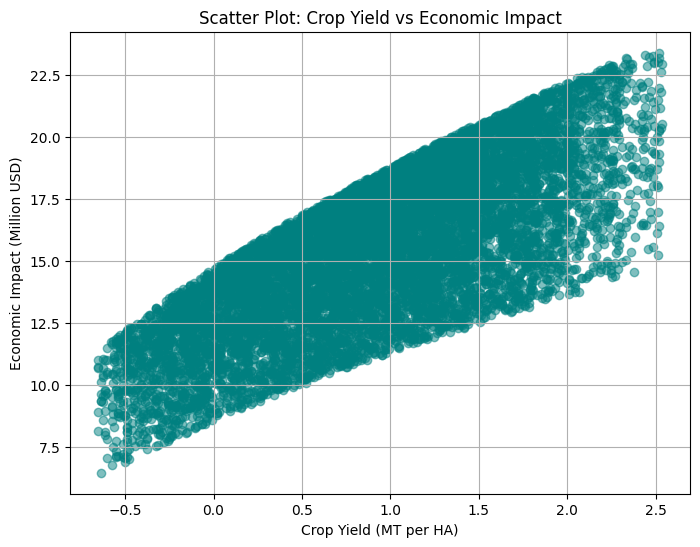

In [ ]:
# Scatter plot antara Crop Yield dan Economic Impact
plt.figure(figsize=(8, 6))
plt.scatter(df['Crop_Yield_MT_per_HA'], df['Economic_Impact_Million_USD'], alpha=0.5, color='teal')
plt.title('Scatter Plot: Crop Yield vs Economic Impact')
plt.xlabel('Crop Yield (MT per HA)')
plt.ylabel('Economic Impact (Million USD)')
plt.grid(True)
plt.show()

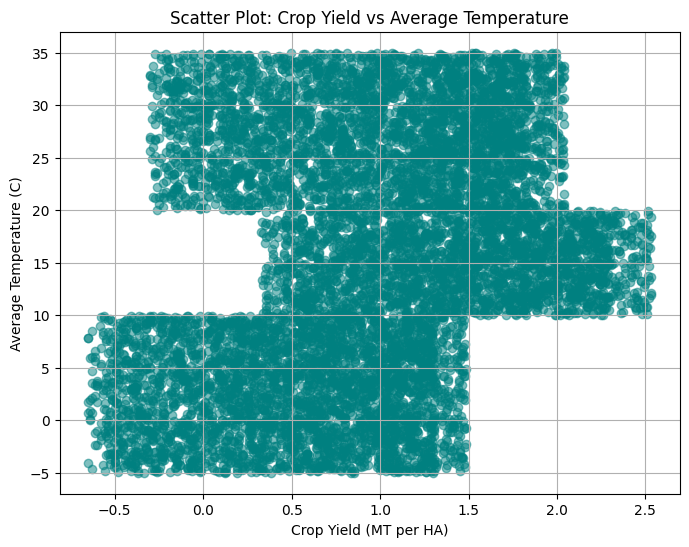

In [ ]:
# Scatter plot antara Crop Yield dan Economic Impact
plt.figure(figsize=(8, 6))
plt.scatter(df['Crop_Yield_MT_per_HA'], df['Average_Temperature_C'], alpha=0.5, color='teal')
plt.title('Scatter Plot: Crop Yield vs Average Temperature')
plt.xlabel('Crop Yield (MT per HA)')
plt.ylabel('Average Temperature (C)')
plt.grid(True)
plt.show()

## **5. Cleaning Data (Membersihkan Data)**

#### Menangani Data yang Hilang (Missing Data)
  Data yang hilang telah dicek pada poin 3 yaitu Validasi data pada sub cek missing value. Sehingga pada bagian ini tidak akan dilakukan hal serupa

#### Check Duplicated Data

In [ ]:
df.duplicated().sum()

np.int64(0)

**Insight :**
- Tidak ada data duplikat dalam data

### **Dropping Irrelevant Columns:**
Year, Country, Region

In [ ]:
# df = df.drop(columns=[col for col in df.columns if col.startswith('Country_') or col.startswith('Region_')])


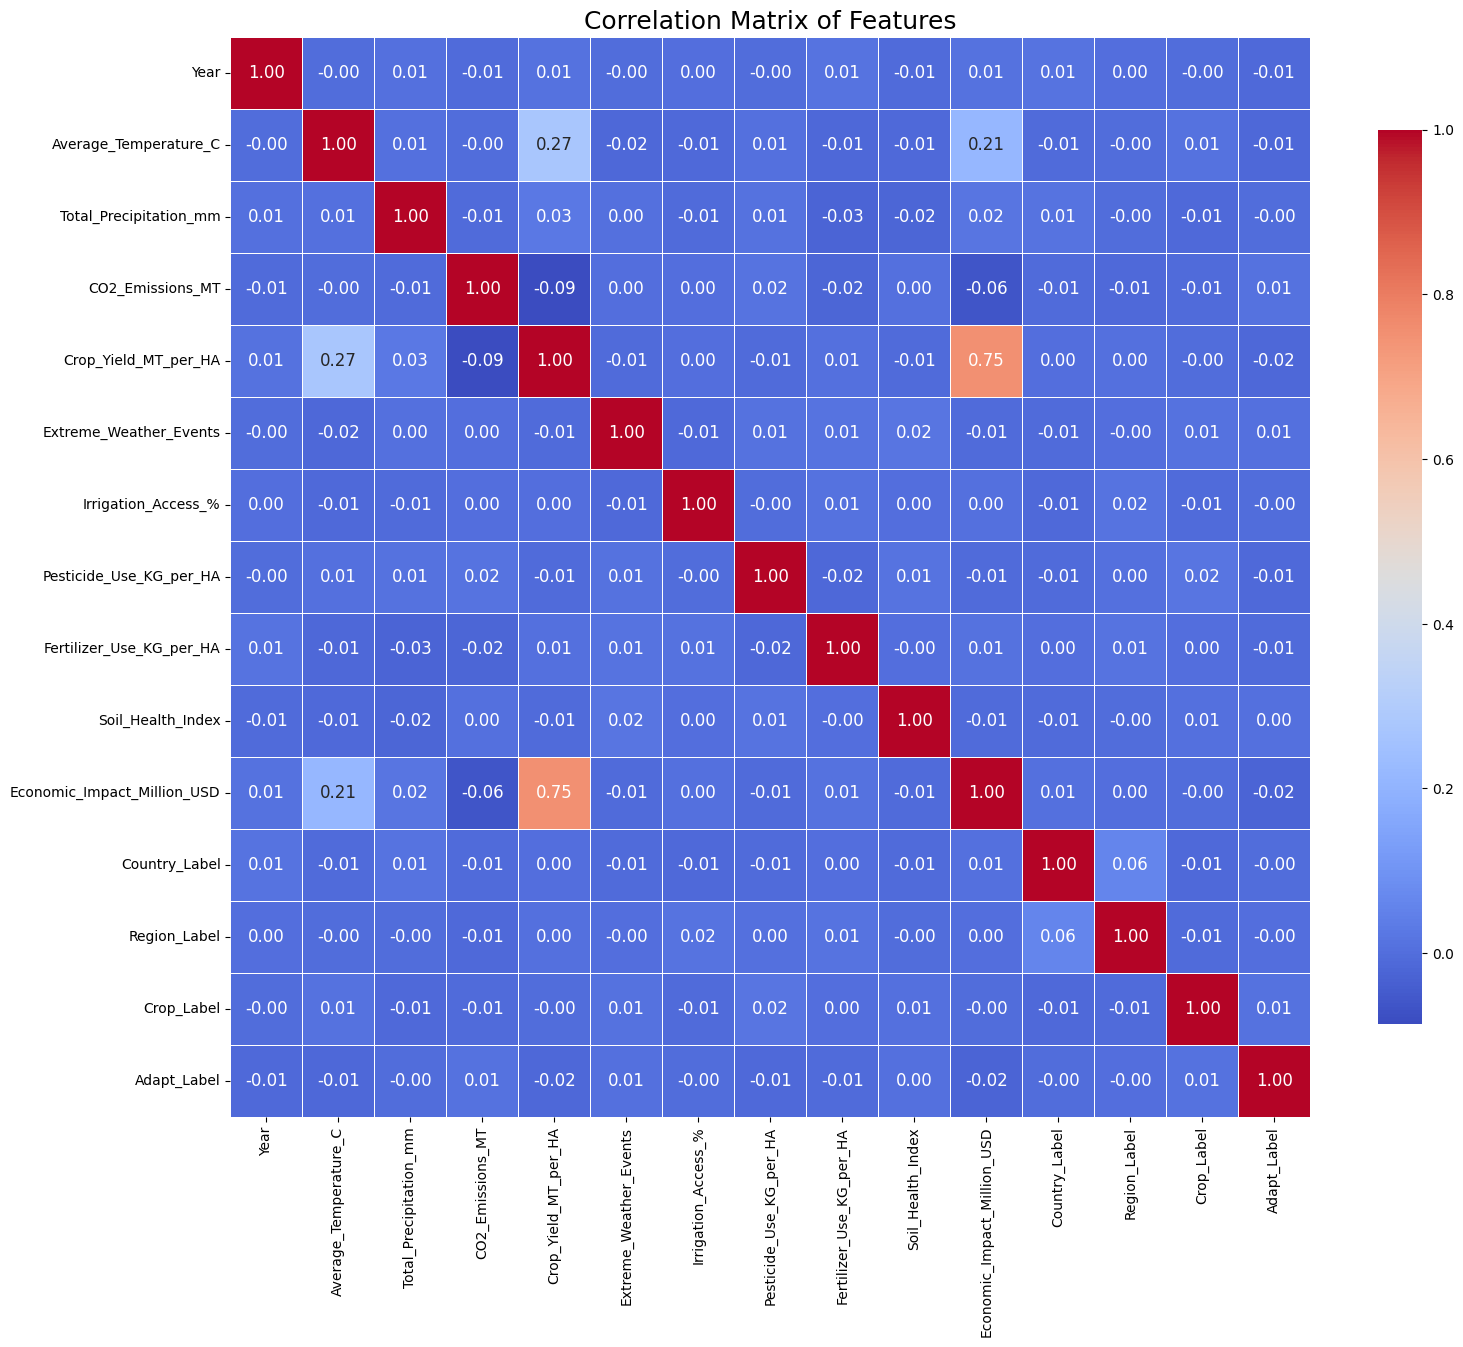

In [ ]:
# Hitung matriks korelasi
correlation_matrix = df.corr(numeric_only=True)

# Atur ukuran plot lebih besar
plt.figure(figsize=(16, 14))

# Visualisasi heatmap dengan parameter annot_kws untuk memperbesar teks
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5,
            square=True,
            annot_kws={"size": 12},  # Menambah ukuran font untuk angka
            cbar_kws={"shrink": .75})

# Judul
plt.title("Correlation Matrix of Features", fontsize=18)
plt.tight_layout()
plt.show()

## **6. Mengkonstruksi Data**

In [ ]:
import numpy as np

# Lambda dari Box-Cox
lambda_yield = 0.5271

# Copy df ke df_balik
df_balik = df.copy()

df_balik['Crop_Yield_MT_per_HA'] = ((df_balik['Crop_Yield_MT_per_HA'] * lambda_yield) + 1) ** (1 / lambda_yield)


In [ ]:
# Membuat kolom-kolom baru di df_balik berdasarkan fitur yang dipilih

# Fitur: Crop Yield per Climate Factor
df_balik['Crop_Yield_per_CO2'] = df_balik['Crop_Yield_MT_per_HA'] / df_balik['CO2_Emissions_MT']
df_balik['Crop_Yield_per_Precipitation'] = df_balik['Crop_Yield_MT_per_HA'] / df_balik['Total_Precipitation_mm']

# Fitur: Soil Health Impact
df_balik['Soil_Health_Impact'] = df_balik['Crop_Yield_MT_per_HA'] * df_balik['Soil_Health_Index']

# Fitur: Climate Stress Indicator
df_balik['Climate_Stress_Indicator'] = df_balik['Average_Temperature_C'] * df_balik['Extreme_Weather_Events']

# Menampilkan 5 baris pertama dari hasil feature engineering
df_balik[['Crop_Yield_per_CO2', 'Crop_Yield_per_Precipitation',
          'Soil_Health_Impact', 'Climate_Stress_Indicator']].head()


,Crop_Yield_per_CO2,Crop_Yield_per_Precipitation,Soil_Health_Impact,Climate_Stress_Indicator
0,0.114126,0.003885,144.605412,12.40
1,0.058250,0.000596,93.832845,25.84
2,0.066757,0.001321,116.513946,105.55
3,0.279657,0.003370,355.509211,139.25
4,0.091448,0.000664,53.578801,19.71


In [ ]:
# prompt: Mau describe kolom ini doang bisa ga??
# # Membuat kolom-kolom baru di df_balik berdasarkan fitur yang dipilih
# # Fitur: Crop Yield per Climate Factor
# df_balik['Crop_Yield_per_CO2'] = df_balik['Crop_Yield_MT_per_HA'] / df_balik['CO2_Emissions_MT']
# df_balik['Crop_Yield_per_Precipitation'] = df_balik['Crop_Yield_MT_per_HA'] / df_balik['Total_Precipitation_mm']
# # Fitur: Soil Health Impact
# df_balik['Soil_Health_Impact'] = df_balik['Crop_Yield_MT_per_HA'] * df_balik['Soil_Health_Index']
# # Fitur: Climate Stress Indicator
# df_balik['Climate_Stress_Indicator'] = df_balik['Average_Temperature_C'] * df_balik['Extreme_Weather_Events']
# # Menampilkan 5 baris pertama dari hasil feature engineering
# df_balik[['Crop_Yield_per_CO2', 'Crop_Yield_per_Precipitation',
#           'Soil_Health_Impact', 'Climate_Stress_Indicator']].head()

print("""
Penjelasan untuk kolom-kolom baru hasil feature engineering:

1.  **Crop_Yield_per_CO2**: Kolom ini mengukur efisiensi produksi tanaman (hasil panen) relatif terhadap emisi CO2. Nilai yang tinggi menunjukkan hasil panen yang baik meskipun ada emisi CO2 yang terkait, atau hasil panen yang tinggi dengan emisi CO2 yang relatif rendah. Ini bisa menjadi indikator keberlanjutan atau dampak lingkungan dari produksi pertanian.

2.  **Crop_Yield_per_Precipitation**: Kolom ini menghitung hasil panen per unit curah hujan. Nilai yang tinggi menunjukkan bahwa tanaman menghasilkan panen yang tinggi meskipun dengan curah hujan yang mungkin terbatas, atau sangat efisien dalam memanfaatkan curah hujan yang tersedia. Ini relevan di daerah yang rentan kekeringan atau dengan pasokan air yang bervariasi.

3.  **Soil_Health_Impact**: Kolom ini mengukur dampak kombinasi dari hasil panen dan indeks kesehatan tanah. Karena hasil panen dikalikan dengan indeks kesehatan tanah, nilai yang tinggi di kolom ini bisa berarti hasil panen tinggi di tanah yang sehat, atau hasil panen yang sangat tinggi meskipun kesehatan tanah tidak optimal (meski skenario ini mungkin kurang mungkin terjadi dalam data nyata). Ini mencoba menangkap bagaimana produktivitas lahan terkait dengan kondisi tanah.

4.  **Climate_Stress_Indicator**: Kolom ini merupakan hasil perkalian antara suhu rata-rata dan jumlah kejadian cuaca ekstrem. Nilai yang tinggi pada kolom ini menunjukkan kondisi iklim yang lebih menantang bagi pertanian, misalnya suhu rata-rata yang tinggi dikombinasikan dengan seringnya kejadian cuaca ekstrem. Kolom ini bertujuan untuk mengukur tingkat 'stress' iklim yang dialami oleh lahan pertanian.
""")



Penjelasan untuk kolom-kolom baru hasil feature engineering:

1.  **Crop_Yield_per_CO2**: Kolom ini mengukur efisiensi produksi tanaman (hasil panen) relatif terhadap emisi CO2. Nilai yang tinggi menunjukkan hasil panen yang baik meskipun ada emisi CO2 yang terkait, atau hasil panen yang tinggi dengan emisi CO2 yang relatif rendah. Ini bisa menjadi indikator keberlanjutan atau dampak lingkungan dari produksi pertanian.

2.  **Crop_Yield_per_Precipitation**: Kolom ini menghitung hasil panen per unit curah hujan. Nilai yang tinggi menunjukkan bahwa tanaman menghasilkan panen yang tinggi meskipun dengan curah hujan yang mungkin terbatas, atau sangat efisien dalam memanfaatkan curah hujan yang tersedia. Ini relevan di daerah yang rentan kekeringan atau dengan pasokan air yang bervariasi.

3.  **Soil_Health_Impact**: Kolom ini mengukur dampak kombinasi dari hasil panen dan indeks kesehatan tanah. Karena hasil panen dikalikan dengan indeks kesehatan tanah, nilai yang tinggi di kolom ini bis

In [ ]:
df_balik.describe()

,Year,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Economic_Impact_Million_USD,Country_Label,Region_Label,Crop_Label,Adapt_Label,Crop_Yield_per_CO2,Crop_Yield_per_Precipitation,Soil_Health_Impact,Climate_Stress_Indicator
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2007.088700,15.241299,1611.663834,15.246608,2.240024,4.980900,55.248332,24.955735,49.973708,64.901278,15.415740,4.521500,16.076800,4.557100,2.016400,0.322369,0.002095,145.265683,75.305267
std,10.084245,11.466955,805.016815,8.589423,0.998349,3.165808,25.988305,14.490962,28.711027,20.195882,3.115796,2.873946,9.667236,2.869384,1.413977,0.561566,0.002138,81.611550,82.805090
min,1990.000000,-4.990000,200.150000,0.500000,0.450001,0.000000,10.010000,0.000000,0.010000,30.000000,6.467156,0.000000,0.000000,0.000000,0.000000,0.015496,0.000156,14.809544,-49.300000
25%,1999.000000,5.430000,925.697500,7.760000,1.449001,2.000000,32.677500,12.527500,25.390000,47.235000,13.134805,2.000000,8.000000,2.000000,1.000000,0.085182,0.000859,82.435225,8.475000
50%,2007.000000,15.175000,1611.160000,15.200000,2.170005,5.000000,55.175000,24.930000,49.635000,64.650000,15.438151,5.000000,16.000000,5.000000,2.000000,0.144614,0.001400,129.487374,48.700000
75%,2016.000000,25.340000,2306.997500,22.820000,2.930011,8.000000,77.582500,37.470000,74.825000,82.472500,17.734333,7.000000,24.000000,7.000000,3.000000,0.302521,0.002420,192.072762,123.285000
max,2024.000000,35.000000,2999.670000,30.000000,5.000040,10.000000,99.990000,49.990000,99.990000,100.000000,23.407128,9.000000,33.000000,9.000000,4.000000,6.794168,0.022050,493.475232,349.000000


1. Crop_Yield_per_CO2 (Hasil Panen per Emisi CO2)

    Insight:

      -  Kolom ini menggambarkan rasio antara hasil panen per hektar (Crop_Yield_MT_per_HA) dan emisi CO2 (CO2_Emissions_MT). Hal ini memberikan gambaran seberapa efisien hasil pertanian dibandingkan dengan dampak emisi karbon yang dihasilkan.

      -  Dengan nilai rata-rata 0.135465, ini menunjukkan bahwa secara umum, hasil panen per unit emisi CO2 cenderung rendah. Ini mungkin mengindikasikan bahwa meskipun ada upaya untuk meningkatkan hasil pertanian, emisi CO2 tetap relatif tinggi dalam banyak kasus, yang bisa menjadi area yang perlu mendapat perhatian dalam upaya mitigasi perubahan iklim.

2. Crop_Yield_per_Precipitation (Hasil Panen per Presipitasi)

    Insight:

      -  Kolom ini menggambarkan rasio antara hasil panen per hektar (Crop_Yield_MT_per_HA) dan jumlah total presipitasi (Total_Precipitation_mm). Rasio ini berguna untuk menilai bagaimana hasil pertanian dipengaruhi oleh curah hujan, yang merupakan salah satu indikator penting terkait perubahan iklim.

      -  Dengan nilai rata-rata yang sangat rendah (0.000859), dapat terlihat bahwa hasil panen sangat sedikit dipengaruhi oleh curah hujan, atau ada variabilitas tinggi dalam bagaimana tanaman merespons presipitasi, mungkin dikarenakan faktor lain seperti praktik irigasi atau ketahanan tanaman terhadap kondisi cuaca ekstrem.

3. Soil_Health_Impact (Dampak Kesehatan Tanah terhadap Hasil Panen)

    Insight:

      -  Kolom ini adalah hasil perkalian antara hasil panen per hektar (Crop_Yield_MT_per_HA) dan indeks kesehatan tanah (Soil_Health_Index). Ini memberikan informasi tentang seberapa besar kontribusi kesehatan tanah terhadap hasil pertanian yang dihasilkan.

      -  Nilai rata-rata 60.126944 menunjukkan bahwa kesehatan tanah memiliki peran yang signifikan dalam meningkatkan hasil pertanian. Tanah yang lebih sehat kemungkinan dapat mendukung hasil pertanian yang lebih tinggi, yang menunjukkan pentingnya pengelolaan tanah yang baik dalam praktik pertanian berkelanjutan.

4. Climate_Stress_Indicator (Indikator Stres Iklim)

    Insight:

      -  Kolom ini adalah hasil perkalian antara suhu rata-rata tahunan (Average_Temperature_C) dan jumlah peristiwa cuaca ekstrem (Extreme_Weather_Events). Ini memberi gambaran mengenai tingkat stres iklim yang dihadapi oleh wilayah tertentu berdasarkan suhu dan frekuensi kejadian cuaca ekstrem.

      -  Dengan nilai rata-rata 75.305267, kolom ini mengindikasikan tingkat stres iklim yang tinggi di sebagian besar data, yang bisa menjadi indikator penting dalam memahami bagaimana perubahan iklim mempengaruhi hasil pertanian, terutama di wilayah yang lebih rentan terhadap fenomena cuaca ekstrem.



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Year                            10000 non-null  int64  
 1   Country                         10000 non-null  object 
 2   Region                          10000 non-null  object 
 3   Crop_Type                       10000 non-null  object 
 4   Average_Temperature_C           10000 non-null  float64
 5   Total_Precipitation_mm          10000 non-null  float64
 6   CO2_Emissions_MT                10000 non-null  float64
 7   Crop_Yield_MT_per_HA            10000 non-null  float64
 8   Extreme_Weather_Events          10000 non-null  int64  
 9   Irrigation_Access_%             10000 non-null  float64
 10  Pesticide_Use_KG_per_HA         10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA        10000 non-null  float64
 12  Soil_Health_Index               1

In [ ]:
# cols_to_drop = [
#     'Crop_Yield_MT_per_HA',        # target
#     'Country', 'Region', 'Crop_Type', 'Adaptation_Strategies',  # kolom asli kategori (string)
#     'Country_Original', 'Region_Original', 'Crop_Type_Original', 'Adaptation_Strategies_Original'  # kolom backup kategori (string)
# ]

In [ ]:
X = df.drop(columns=[
    'Crop_Yield_MT_per_HA',        # target
    'Country', 'Region', 'Crop_Type', 'Adaptation_Strategies',  # kolom asli kategori (string)
    'Country_Original', 'Region_Original', 'Crop_Type_Original', 'Adaptation_Strategies_Original'  # kolom backup kategori (string)
])

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         10000 non-null  int64  
 1   Average_Temperature_C        10000 non-null  float64
 2   Total_Precipitation_mm       10000 non-null  float64
 3   CO2_Emissions_MT             10000 non-null  float64
 4   Extreme_Weather_Events       10000 non-null  int64  
 5   Irrigation_Access_%          10000 non-null  float64
 6   Pesticide_Use_KG_per_HA      10000 non-null  float64
 7   Fertilizer_Use_KG_per_HA     10000 non-null  float64
 8   Soil_Health_Index            10000 non-null  float64
 9   Economic_Impact_Million_USD  10000 non-null  float64
 10  Country_Label                10000 non-null  int64  
 11  Region_Label                 10000 non-null  int64  
 12  Crop_Label                   10000 non-null  int64  
 13  Adapt_Label      

In [ ]:
# Menentukan X dan y
# X = df.drop(columns=['Crop_Yield_MT_per_HA', 'Crop_Type', 'Adaptation_Strategies'])
y = df['Crop_Yield_MT_per_HA']

In [ ]:
# Import the necessary module
from sklearn.model_selection import train_test_split

# Membagi data menjadi 80% untuk training dan 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:


# Membagi data menjadi 80% untuk training dan 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Import the necessary module
from sklearn.preprocessing import StandardScaler

# Standardisasi data (scaling) menggunakan StandardScaler
scaler = StandardScaler()

# Fit scaler ke training data
X_train_scaled = scaler.fit_transform(X_train)

# Terapkan scaler pada data testing
X_test_scaled = scaler.transform(X_test)

## **7. Modeling dan Evaluasi**

### NN

In [ ]:
from scipy.special import inv_boxcox
import numpy as np


Evaluating batch_size=16, epochs=10 with 5-Fold CV
  Fold 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Fold 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Fold 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Fold 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Fold 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
  Average RMSE for this config: 0.6613

Evaluating batch_size=16, epochs=20 with 5-Fold CV
  Fold 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
  Fold 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
  Fold 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
  Fold 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Fold 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Average RMSE for this config: 0.6899

Evaluating batch_size=32, epochs=10 with 5-Fold CV
  Fold 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Fold 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Fold 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Fold 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
  Fold 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
  Average RMSE f

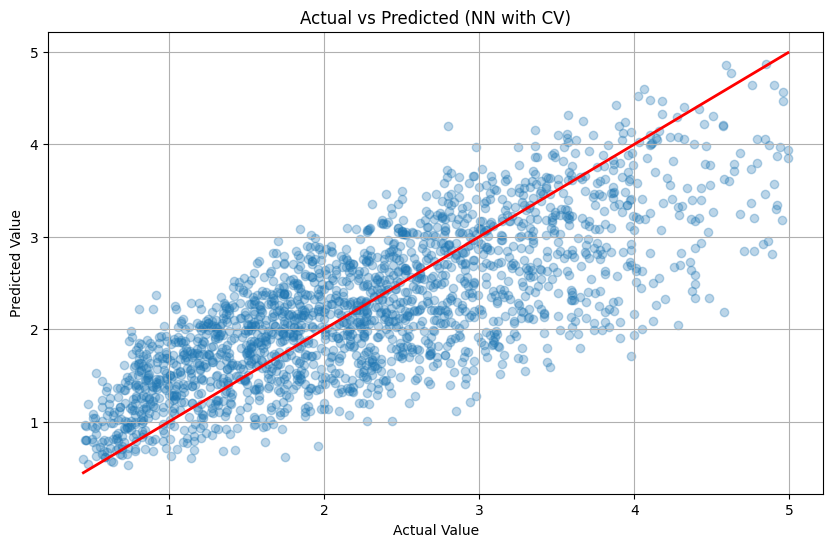

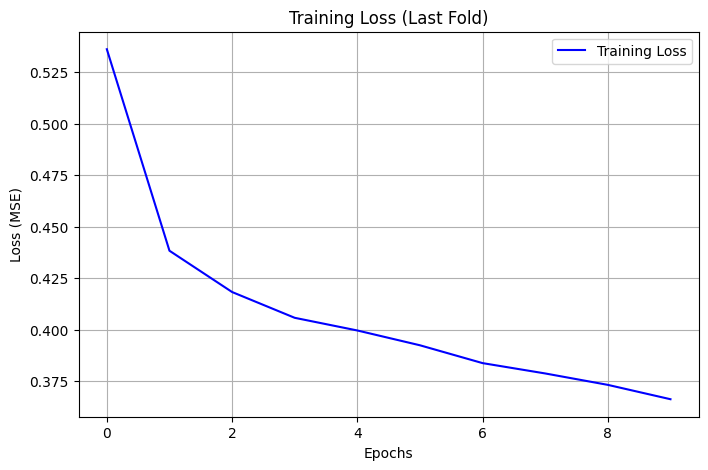

In [ ]:
# Import necessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scipy.special import inv_boxcox  # Untuk inverse Box-Cox

# === GANTI DENGAN DATA KAMU SENDIRI ===
# X = ...
# y = ...
# =====================================

# Misal diketahui lambda Box-Cox
lmbda_boxcox = 0.5271  # Sesuaikan dengan hasil transformasi Box-Cox kamu

# Build Neural Network model
def build_nn_model(input_dim, optimizer='adam'):
    model = Sequential()
    model.add(Dense(units=64, activation='relu', input_dim=input_dim))
    model.add(Dense(units=32, activation='relu'))
    model.add(Dense(units=16, activation='relu'))
    model.add(Dense(units=1))
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Split data awal: train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Simpan test scaler untuk evaluasi akhir
scaler_X_test = StandardScaler()
scaler_y_test = StandardScaler()
X_test_scaled = scaler_X_test.fit_transform(X_test)
y_test_scaled = scaler_y_test.fit_transform(y_test.values.reshape(-1, 1))

# Hyperparameter grid
param_grid = {
    'batch_size': [16, 32],
    'epochs': [10, 20]
}

# K-Fold setup
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

best_rmse = float('inf')
best_params = {}
best_model = None
best_history = None

# Grid search with K-Fold
for batch_size in param_grid['batch_size']:
    for epochs in param_grid['epochs']:
        print(f"\nEvaluating batch_size={batch_size}, epochs={epochs} with {k}-Fold CV")
        rmse_folds = []

        for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
            print(f"  Fold {fold+1}/{k}")
            X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
            y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

            # Scaling
            scaler_X = StandardScaler()
            scaler_y = StandardScaler()
            X_tr_scaled = scaler_X.fit_transform(X_tr)
            X_val_scaled = scaler_X.transform(X_val)
            y_tr_scaled = scaler_y.fit_transform(y_tr.values.reshape(-1, 1))
            y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))

            # Build and train model
            model = build_nn_model(input_dim=X_tr_scaled.shape[1])
            history = model.fit(X_tr_scaled, y_tr_scaled,
                                epochs=epochs,
                                batch_size=batch_size,
                                verbose=0)

            # Predict and inverse-transform
            y_val_pred_scaled = model.predict(X_val_scaled)
            y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled)
            y_val_pred_final = inv_boxcox(y_val_pred.flatten(), lmbda_boxcox)
            y_val_original = inv_boxcox(y_val.values.flatten(), lmbda_boxcox)

            # RMSE for this fold
            rmse_fold = np.sqrt(mean_squared_error(y_val_original, y_val_pred_final))
            rmse_folds.append(rmse_fold)

        avg_rmse = np.mean(rmse_folds)
        print(f"  Average RMSE for this config: {avg_rmse:.4f}")

        if avg_rmse < best_rmse:
            best_rmse = avg_rmse
            best_params = {'batch_size': batch_size, 'epochs': epochs}
            best_model = model  # last model from last fold
            best_history = history

print("\nBest hyperparameters from CV:", best_params)

# === Evaluasi di Test Set ===
y_test_pred_scaled = best_model.predict(X_test_scaled)
y_test_pred = scaler_y_test.inverse_transform(y_test_pred_scaled)
y_test_pred_final = inv_boxcox(y_test_pred.flatten(), lmbda_boxcox)
y_test_original = inv_boxcox(y_test.values.flatten(), lmbda_boxcox)

rmse_test = np.sqrt(mean_squared_error(y_test_original, y_test_pred_final))
mae_test = mean_absolute_error(y_test_original, y_test_pred_final)
r2_test = r2_score(y_test_original, y_test_pred_final)

print(f"\nFinal Model Evaluation on Test Set:")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE: {mae_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Buat dataframe perbandingan hasil prediksi
comparison_df = pd.DataFrame({
    'Actual Value': y_test_original,
    'Predicted Value': y_test_pred_final
})
print("\nSample predictions:")
print(comparison_df.head())

# Plot scatter Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_test_pred_final, alpha=0.3)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], color='red', linewidth=2)
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted (NN with CV)")
plt.grid(True)
plt.show()

# Plot training loss (from last fold)
plt.figure(figsize=(8, 5))
plt.plot(best_history.history['loss'], label='Training Loss', color='blue')
plt.title("Training Loss (Last Fold)")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


NN lebih bagus karena dia dikombinasiin juga di hidden layernya, makanya dia lebih cepet jugaa

RFR

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found:  {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Evaluasi Model Random Forest (setelah inverse Box-Cox):
RMSE : 0.6246
MAE  : 0.4988
R²   : 0.6303

Sample predictions:
   Actual Price  Predicted Price
0      0.639001         0.716106
1      4.100026         3.127912
2      2.520007         2.775695
3      1.520001         2.439640
4      1.593001         1.817981


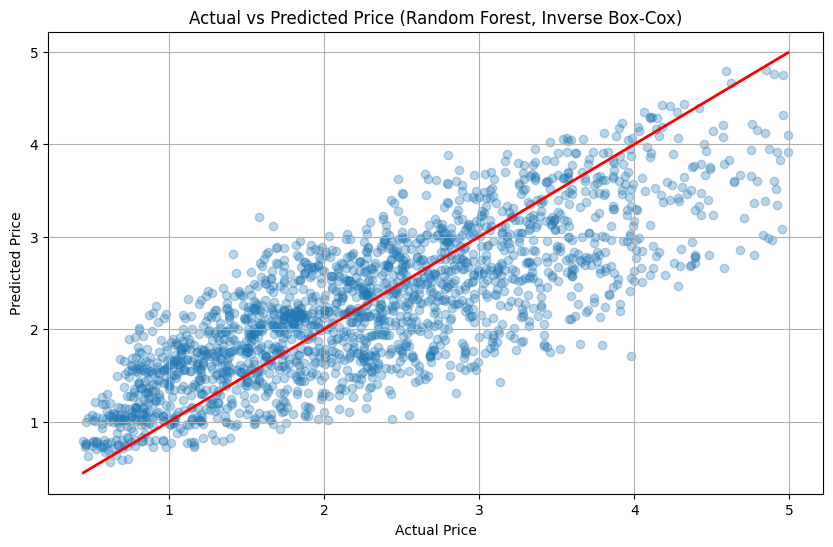

In [ ]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.special import inv_boxcox  # Untuk inverse Box-Cox

# Asumsikan lambda Box-Cox sudah diketahui
lmbda_boxcox = 0.5271  # Ganti sesuai hasilmu

# Inisialisasi model Random Forest Regressor
rf_regressor = RandomForestRegressor(random_state=42)

# Parameter grid untuk tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}

# GridSearchCV untuk mencari parameter terbaik
grid_search = GridSearchCV(
    estimator=rf_regressor,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error'
)

# Melatih model
grid_search.fit(X_train, y_train)

# Menampilkan parameter terbaik
print("Best parameters found: ", grid_search.best_params_)

# Menggunakan model terbaik dari hasil grid search
best_rf_model = grid_search.best_estimator_

# Prediksi pada data uji
y_pred = best_rf_model.predict(X_test)

# Inverse Box-Cox transform hasil prediksi dan y_test
y_pred_inv = inv_boxcox(y_pred, lmbda_boxcox)
y_test_inv = inv_boxcox(y_test.values.flatten(), lmbda_boxcox)

# Evaluasi performa
rmse_rf = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae_rf = mean_absolute_error(y_test_inv, y_pred_inv)
r2_rf = r2_score(y_test_inv, y_pred_inv)

# Tampilkan hasil evaluasi
print(f"\nEvaluasi Model Random Forest (setelah inverse Box-Cox):")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

# Buat DataFrame perbandingan
comparison_df = pd.DataFrame({
    'Actual Price': y_test_inv,
    'Predicted Price': y_pred_inv
})

# Tampilkan beberapa baris
print("\nSample predictions:")
print(comparison_df.head())

# Plot Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_inv, y_pred_inv, alpha=0.3)
plt.plot([min(y_test_inv), max(y_test_inv)], [min(y_test_inv), max(y_test_inv)], color='red', linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Random Forest, Inverse Box-Cox)")
plt.grid(True)
plt.show()
